# Feature Selection

This notebook reuses the already preprocessed data from `Preprocessment.ipynb` and applies:
1. Pearson correlation (numeric features vs target)
2. Logistic Regression
3. Random Forest feature importance

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

TARGET_COL = "y"
RANDOM_STATE = 42

In [12]:
X_train = pd.read_csv(Path(r"data/X_train_processed.csv"))
X_test = pd.read_csv(Path(r"data/X_test_processed.csv"))
y_train = pd.read_csv(Path(r"data/y_train.csv"))
y_test = pd.read_csv(Path(r"data/y_test.csv"))

y_train = y_train.squeeze("columns")
y_test = y_test.squeeze("columns")

y_train = y_train.map({"yes": 1, "no": 0})
y_test = y_test.map({"yes": 1, "no": 0})


#drop the duration column
X_train.drop(columns=["duration"], inplace=True)
X_test.drop(columns=["duration"], inplace=True)


print(f"Train preprocessed shape: {X_train.shape}")
print(f"Test preprocessed shape:  {X_test.shape}")

Train preprocessed shape: (36168, 25)
Test preprocessed shape:  (9043, 25)


## 1) Pearson Correlation

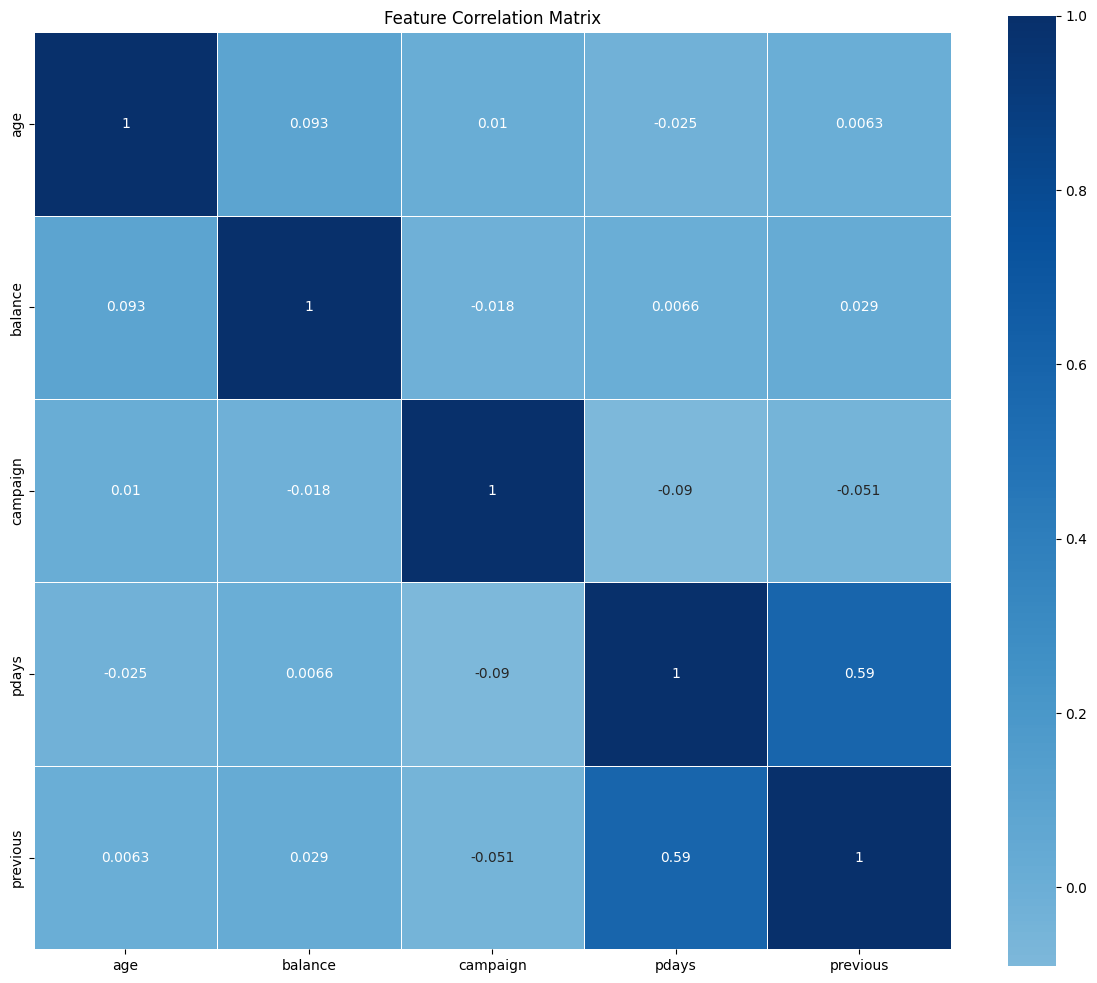

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# correlation matrix between features
corr_map = X_train[numeric_cols].corr()

# filter the variables with valuue_counts length greater than 2
filtered_cols = [col for col in numeric_cols if X_train[col].nunique() > 2]
filtered_corr_map = X_train[filtered_cols].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    filtered_corr_map,
    cmap="Blues",
    center=0,
    square=True,
    annot=True,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [14]:
# combine features with target
corr_df = X_train.copy()
corr_df["target"] = y_train

# calculate Pearson correlation with target
pearson_corr = corr_df.corr()["target"].drop("target")

# Create a clean dataframe
pearson_corr_df = pd.DataFrame({
    "pearson_corr": pearson_corr,
    "abs_pearson_corr": pearson_corr.abs()
}).sort_values("abs_pearson_corr", ascending=False)

# Show top features
print("Top features by Pearson correlation with target:")
display(pearson_corr_df.head(20))


Top features by Pearson correlation with target:


,pearson_corr,abs_pearson_corr
poutcome_success,0.305847,0.305847
housing_yes,-0.139432,0.139432
previous,0.127848,0.127848
pdays,0.098197,0.098197
job_retired,0.080458,0.080458
job_student,0.078270,0.078270
campaign,-0.073254,0.073254
job_blue-collar,-0.071168,0.071168
loan_yes,-0.066525,0.066525
marital_single,0.064686,0.064686


In [15]:
## 2) Logistic Regression
for c in [1, 0.5, 0.1, 0.05, 0.01]:
    model = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=c,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    coefficients = pd.Series(model.coef_[0], index=X_train.columns)

    selected_features = coefficients[coefficients != 0].index.tolist()

    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]

    #print selected features with the length of the list and the value of c
    print(f"C: {c} - Selected features: {len(selected_features)} - {selected_features}")


C: 1 - Selected features: 25 - ['age', 'balance', 'campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'poutcome_other', 'poutcome_success']
C: 0.5 - Selected features: 25 - ['age', 'balance', 'campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'poutcome_other', 'poutcome_success']
C: 0.1 - Selected features: 23 - ['balance', 'campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entreprene

## 3) Random Forest Importance

In [16]:
# One-hot encode categoricals for Random Forest
X_train_encoded = X_train.copy()

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced",
    max_depth=5,
    max_features="sqrt",
)
rf.fit(X_train_encoded, y_train)

rf_importance_encoded = pd.Series(rf.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)
rf_importance_encoded.head(30)

poutcome_success       0.268423
housing_yes            0.155218
pdays                  0.139201
previous               0.110732
age                    0.095630
balance                0.068577
campaign               0.030715
marital_married        0.023536
marital_single         0.022914
loan_yes               0.020809
job_blue-collar        0.019282
job_retired            0.014138
education_tertiary     0.009309
job_student            0.008929
poutcome_other         0.002376
job_management         0.002328
education_secondary    0.001375
contact_telephone      0.001122
job_entrepreneur       0.001082
job_technician         0.000903
default_yes            0.000901
job_housemaid          0.000890
job_services           0.000808
job_self-employed      0.000425
job_unemployed         0.000380
dtype: float64

In [19]:
TOP_K_RF = 26
selected_by_rf = rf_importance_encoded.head(TOP_K_RF).index.tolist()

print(f"Random Forest selected top-{TOP_K_RF} features: {len(selected_by_rf)}")
selected_by_rf

Random Forest selected top-26 features: 25


['poutcome_success',
 'housing_yes',
 'pdays',
 'previous',
 'age',
 'balance',
 'campaign',
 'marital_married',
 'marital_single',
 'loan_yes',
 'job_blue-collar',
 'job_retired',
 'education_tertiary',
 'job_student',
 'poutcome_other',
 'job_management',
 'education_secondary',
 'contact_telephone',
 'job_entrepreneur',
 'job_technician',
 'default_yes',
 'job_housemaid',
 'job_services',
 'job_self-employed',
 'job_unemployed']

In [20]:
X_traiun_rf_selected = X_train[selected_by_rf]
X_test_rf_selected = X_test[selected_by_rf]

## Final Selected Features

In [21]:
X_train.to_csv(Path(r"data/X_train_selected.csv"), index=False)
X_test.to_csv(Path(r"data/X_test_selected.csv"), index=False)
y_train.to_csv(Path(r"data/y_train.csv"), index=False)
y_test.to_csv(Path(r"data/y_test.csv"), index=False)